# Exercícios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

## 1.

Carregue o conjunto de dados "breast_cancer" usando a função "load_breast_cancer()".

In [2]:
#load data
cancer = load_breast_cancer()

## 2.

 Faça uma divisão treino/teste com os valores por omissão (treino=75%, teste=25%) e confirme o
número de exemplos e atributos de cada conjunto.


In [3]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
	cancer.data, cancer.target, stratify=cancer.target, random_state=0)

In [4]:
#número de exemplos e atributos de cada conjunto
print("Conjunto de treino:", X_train.shape)
print("Conjunto de teste:", X_test.shape)

Conjunto de treino: (426, 30)
Conjunto de teste: (143, 30)


## 3.

Construa um modelo usando o algoritmo Support Vector Machines (SVM) com um núcleo 'rbf' e
'gamma=1/n_features'. Calcule o desempenho sobre ambos os conjuntos.


In [5]:
# X_train.shape[1]       #n_features
gamma_val = 1 / X_train.shape[1]

svc = SVC(kernel='rbf', gamma=gamma_val)
svc.fit(X_train, y_train)

exatidao_treino = svc.score(X_train, y_train)
exatidao_teste = svc.score(X_test, y_test)

print("Exatidão de treino:", exatidao_treino, "\nExatidão de teste:", exatidao_teste)

Exatidão de treino: 1.0 
Exatidão de teste: 0.6293706293706294


## 4.

Construa um gráfico que mostra os valores mínimo e máximo para cada atributo. Confirme a grande
variabilidade na magnitude dos valores dos atributos. Utilize uma escala logarítmica.


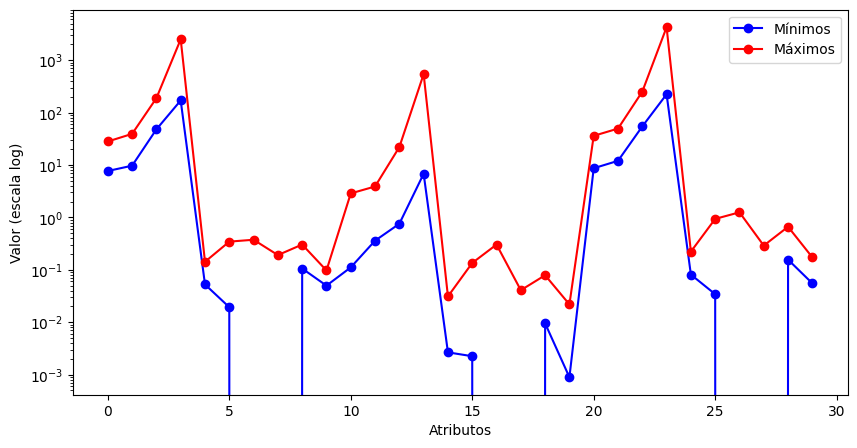

In [6]:
mins = X_train.min(axis=0)
maxs = X_train.max(axis=0)

plt.figure(figsize=(10,5))
plt.plot(mins, 'bo-', label='Mínimos')
plt.plot(maxs, 'ro-', label='Máximos')
plt.yscale('log')
plt.xlabel("Atributos")
plt.ylabel("Valor (escala log)")
plt.legend()
plt.show()

## 5.

A função 'MinMaxScaler' transforma os dados de modo a que qualquer atributo varie entre 0 e 1.
Aplique esta normalização sobre os dados (conjunto de treino) e confirme a transformação
realizada, mostrando os valores mínimo e máximo antes e depois da transformação.


,Min Antes,Max Antes,Min Depois,Max Depois
0,7.69100,28.1100,0.0,1.0
1,9.71000,39.2800,0.0,1.0
2,47.92000,188.5000,0.0,1.0
3,170.40000,2501.0000,0.0,1.0
4,0.05263,0.1425,0.0,1.0


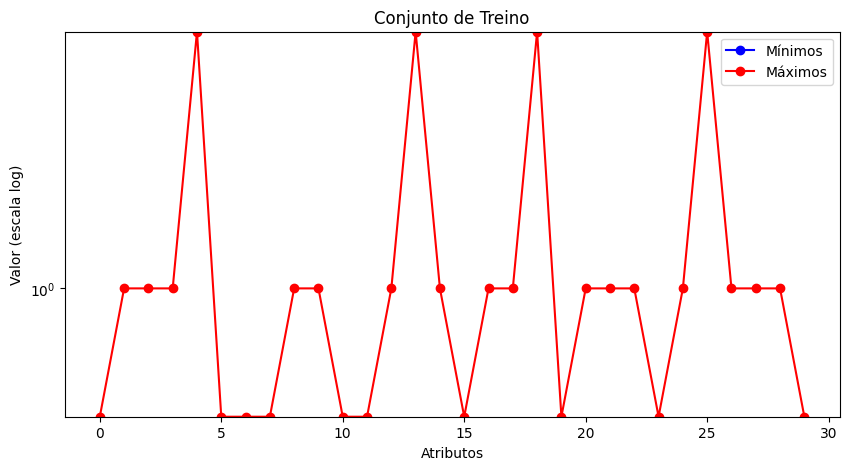

In [7]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

min_antes = X_train.min(axis=0)
max_antes = X_train.max(axis=0)
min_depois = X_train_scaled.min(axis=0)
max_depois = X_train_scaled.max(axis=0)

df = pd.DataFrame({
    'Min Antes': min_antes,
    'Max Antes': max_antes,
    'Min Depois': min_depois,
    'Max Depois': max_depois
}, index=[f'{i}' for i in range(X_train.shape[1])])
display(df.head())

plt.figure(figsize=(10,5))
plt.plot(min_depois, 'bo-', label='Mínimos')
plt.plot(max_depois, 'ro-', label='Máximos')
plt.title('Conjunto de Treino')
plt.yscale('log')
plt.xlabel("Atributos")
plt.ylabel("Valor (escala log)")
plt.legend()
plt.show()

## 6.

Transforme igualmente o conj de teste (usando a mesma transformação realizada sobre o conj de
treino). Confirme a amplitude dos atributos no conj de teste.


,Min Antes,Max Antes,Min Depois,Max Depois
0,6.98100,24.2500,0.0,1.0
1,12.17000,32.4700,0.0,1.0
2,43.79000,166.2000,0.0,1.0
3,143.50000,1761.0000,0.0,1.0
4,0.06613,0.1634,0.0,1.0


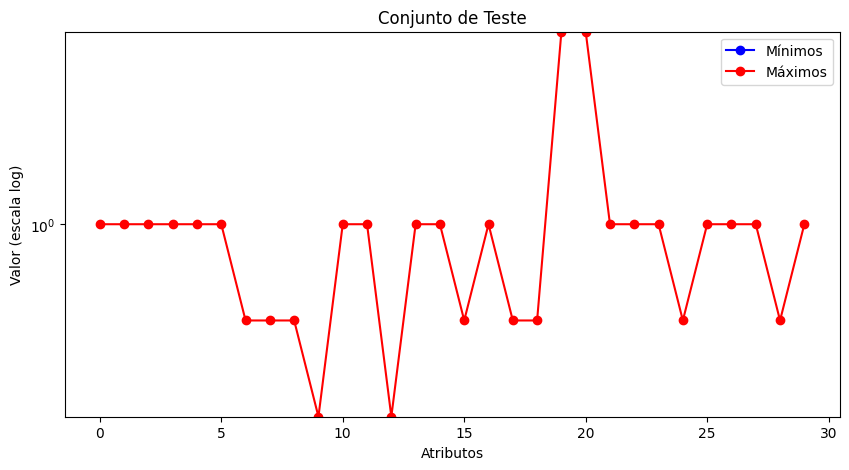

In [8]:
scaler = MinMaxScaler()
X_test_scaled = scaler.fit_transform(X_test)

min_antes = X_test.min(axis=0)
max_antes = X_test.max(axis=0)
min_depois = X_test_scaled.min(axis=0)
max_depois = X_test_scaled.max(axis=0)

df = pd.DataFrame({
    'Min Antes': min_antes,
    'Max Antes': max_antes,
    'Min Depois': min_depois,
    'Max Depois': max_depois
}, index=[f'{i}' for i in range(X_test.shape[1])])
display(df.head())

plt.figure(figsize=(10,5))
plt.plot(min_depois, 'bo-', label='Mínimos')
plt.plot(max_depois, 'ro-', label='Máximos')
plt.title('Conjunto de Teste')
plt.yscale('log')
plt.xlabel("Atributos")
plt.ylabel("Valor (escala log)")
plt.legend()
plt.show()

## 7.

Construa um novo modelo com o mesmo setup do ponto 3, mas agora utilizando os atributos
normalizados. Calcule o desempenho sobre ambos os conjuntos (treino e teste) e compare os
resultados.


In [9]:
gamma_val = 1 / X_train.shape[1]

svc_scaled = SVC(kernel='rbf', gamma=gamma_val)
svc_scaled.fit(X_train_scaled, y_train)

exatidao_treino = svc_scaled.score(X_train_scaled, y_train)
exatidao_teste = svc_scaled.score(X_test_scaled, y_test)

print("Exatidão de treino:", exatidao_treino, "\nExatidão de teste:", exatidao_teste)

Exatidão de treino: 0.9553990610328639 
Exatidão de teste: 0.916083916083916


## 8.

Se considerar que pode existir sub-ajustamento, o que deve fazer? Construa um novo modelo com
um valor de C mais adequado e compare os resultados.

In [10]:
gamma_val = 1 / X_train.shape[1]

svc_scaled_C = SVC(kernel='rbf', gamma=gamma_val, C=10)
svc_scaled_C.fit(X_train_scaled, y_train)

exatidao_treino = svc_scaled_C.score(X_train_scaled, y_train)
exatidao_teste = svc_scaled_C.score(X_test_scaled, y_test)

print("Exatidão de treino:", exatidao_treino, "\nExatidão de teste:", exatidao_teste)

Exatidão de treino: 0.9859154929577465 
Exatidão de teste: 0.9230769230769231
